In [86]:
print("funciona")

funciona


In [2]:
#pip install pandas matplotlib seaborn scikit-learn

In [3]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("titanic_original.csv")
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1.0,1.0,"Allen, Miss. Elisabeth Walton",female,29.0000,0.0,0.0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1.0,1.0,"Allison, Master. Hudson Trevor",male,0.9167,1.0,2.0,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1.0,0.0,"Allison, Miss. Helen Loraine",female,2.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1.0,0.0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1.0,0.0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1.0,2.0,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1310 entries, 0 to 1309
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   float64
 1   survived   1309 non-null   float64
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   float64
 6   parch      1309 non-null   float64
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(7), str(7)
memory usage: 143.4 KB


In [ ]:
# Eliminar columnas específicas
df_elim = df.drop(['pclass', 'cabin', 'boat', 'body', 'sibsp','parch','home.dest'], axis=1)
df_elim = df_elim.dropna()
# Verifico que se eliminaron
print("Columnas después de eliminar:")
print(df_elim.columns.tolist())

Columnas después de eliminar:
['survived', 'name', 'sex', 'age', 'ticket', 'fare', 'embarked']


In [ ]:
# Convertir columnas a entero
df_elim['survived'] = df_elim['survived'].astype(int)
df_elim['age'] = df_elim['age'].astype(int)
df_elim['fare'] = df_elim['fare'].round(2)

In [ ]:
# Ver las primeras filas de midataset despúes de eliminar columnas
print("\nDATA CON LA QUE TRABAJARE:")
print(df_elim.head())


DATA CON LA QUE TRABAJARE:
   survived                                             name     sex  age  \
0         1                    Allen, Miss. Elisabeth Walton  female   29   
1         1                   Allison, Master. Hudson Trevor    male    0   
2         0                     Allison, Miss. Helen Loraine  female    2   
3         0             Allison, Mr. Hudson Joshua Creighton    male   30   
4         0  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female   25   

   ticket    fare embarked  
0   24160  211.34        S  
1  113781  151.55        S  
2  113781  151.55        S  
3  113781  151.55        S  
4  113781  151.55        S  


## Analísis Simple

In [85]:
# Las 5 personas más mayores
print("LAS 5 MÁS MAYORES:")
print(df_elim.nlargest(5, 'age')[['name', 'age']])

# Las 5 personas más jóvenes
print("\nLAS 5 MÁS JÓVENES:")
print(df_elim.nsmallest(5, 'age')[['name', 'age']])

LAS 5 MÁS MAYORES:
                                                   name  age
14                 Barkworth, Mr. Algernon Henry Wilson   80
61    Cavendish, Mrs. Tyrell William (Julia Florence...   76
1235                                Svensson, Mr. Johan   74
9                               Artagaveytia, Mr. Ramon   71
135                           Goldschmidt, Mr. George B   71

LAS 5 MÁS JÓVENES:
                                name  age
1     Allison, Master. Hudson Trevor    0
359    Caldwell, Master. Alden Gates    0
427        Hamalainen, Master. Viljo    0
548  Richards, Master. George Sibley    0
590            West, Miss. Barbara J    0


In [40]:
# TOTAL PASAJEROS
# Contar todas las mujeres y todos los hombres
total_mujeres = len(df_elim[df_elim['sex'] == 'female'])
total_hombres = len(df_elim[df_elim['sex'] == 'male'])

# Sumar mujeres + hombres = total de pasajeros
total_pasajeros = total_mujeres + total_hombres

print(f"Total: {total_mujeres} Mujeres + {total_hombres} hombres = {total_pasajeros}")


Total: 386 Mujeres + 657 hombres = 1043


In [61]:
# TOTAL SOBREVIVIENTES
Total_Sobrevivientes= (df_elim['survived'] == 1).sum()
Porcentaje_Sobrev = (Total_Sobrevivientes / total_pasajeros) * 100


# MUJERES
# Filtrar SOLO las mujeres que sobrevivieron
Mujeres_Sobrevivientes = df_elim[(df_elim['sex'] == 'female') & (df_elim['survived'] == 1)]

# Contar cuántas mujeres sobrevivieron
Cantidad_Mujeres_Sobrev = len(Mujeres_Sobrevivientes)

# Calcular porcentaje mujeres sobrevivieron
Porcentaje_MujeresSobrev = (Cantidad_Mujeres_Sobrev / Total_Sobrevivientes) * 100


# HOMBRES
# Filtrar SOLO las hombres que sobrevivieron
Hombres_Sobrevivientes = df_elim[(df_elim['sex'] == 'male') & (df_elim['survived'] == 1)]

# Contar cuántas hombres sobrevivieron
Cantidad_Hombres_Sobrev = len(Hombres_Sobrevivientes)

# Calcular porcentaje hombres sobrevivieron
Porcentaje_HombresSobrev = (Cantidad_Hombres_Sobrev / Total_Sobrevivientes) * 100


# Mostrar resultados
print(f"Total de sobrevivientes: {Total_Sobrevivientes}")
print(f"% sobrevivientes del total de pasajeros: {Porcentaje_Sobrev:.2f}%")
print(f"Mujeres que sobrevivieron: {Cantidad_Mujeres_Sobrev}")
print(f"% mujeres sobrevivientes: {Porcentaje_MujeresSobrev:.2f}%")
print(f"Hombres que sobrevivieron: {Cantidad_Hombres_Sobrev}")
print(f"% hombres  sobrevivientes: {Porcentaje_HombresSobrev:.2f}%")

Total de sobrevivientes: 425
% sobrevivientes del total de pasajeros: 40.75%
Mujeres que sobrevivieron: 290
% mujeres sobrevivientes: 68.24%
Hombres que sobrevivieron: 135
% hombres  sobrevivientes: 31.76%


In [87]:
# TOTAL FALLECIDOS
Total_Fallecidos = (df_elim['survived'] == 0).sum()
Porcentaje_F = (Total_Fallecidos/ total_pasajeros) * 100


# MUJERES
# Filtrar SOLO las mujeres que fallecieron
Mujeres_F = df_elim[(df_elim['sex'] == 'female') & (df_elim['survived'] == 0)]

# Contar cuántas mujeres fallecieron
Cantidad_Mujeres_F = len(Mujeres_F)

# Calcular porcentaje mujeres fallecieron
Porcentaje_MujeresF = (Cantidad_Mujeres_Sobrev / Total_Sobrevivientes) * 100


# HOMBRES
# Filtrar SOLO las hombres que fallecieron
Hombres_F = df_elim[(df_elim['sex'] == 'male') & (df_elim['survived'] == 0)]

# Contar cuántas hombres fallecieron
Cantidad_Hombres_F = len(Hombres_F)

# Calcular porcentaje hombres fallecieron
Porcentaje_HombresF = (Cantidad_Hombres_F/ Total_Sobrevivientes) * 100


# Mostrar resultados
print(f"Total Fallecidos: {Total_Fallecidos}")
print(f"% fallecidos del total de pasajeros: {Porcentaje_F:.2f}%")
print(f"Mujeres que fallecieron: {Cantidad_Mujeres_Sobrev}")
print(f"% mujeres fallecidas: {Porcentaje_MujeresSobrev:.2f}%")
print(f"Hombres que fallecieorn: {Cantidad_Hombres_Sobrev}")
print(f"% hombres fallecidos: {Porcentaje_HombresSobrev:.2f}%")

Total Fallecidos: 618
% fallecidos del total de pasajeros: 59.25%
Mujeres que fallecieron: 290
% mujeres fallecidas: 68.24%
Hombres que fallecieorn: 135
% hombres fallecidos: 31.76%


## Graficas

In [84]:
#Edad Promedio
print(f"Edad promedio: {df_elim['age'].mean():.0f}")

Edad promedio: 30


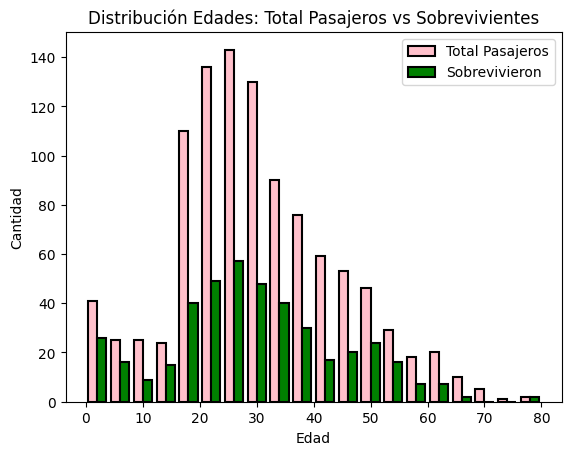

In [74]:
# Filtrar sobrevivientes
sobrevivientes = df_elim[df_elim['survived'] == 1]

# Hacer el histograma con barras una al lado de la otra
plt.hist([df_elim['age'], sobrevivientes['age']], bins=20, label=['Total Pasajeros', 'Sobrevivieron'], color=['Pink', 'green'], 
         edgecolor='black',  # Borde negro 
         linewidth=1.5)      # Grosor del borde

# Títulos
plt.title('Distribución Edades: Total Pasajeros vs Sobrevivientes')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.legend()
plt.show()

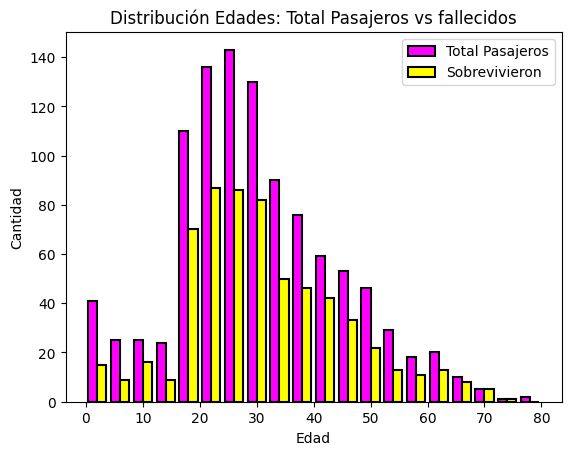

In [ ]:
# Filtrar FALLECIDOS
fallecidos = df_elim[df_elim['survived'] == 0]

# Hacer el histograma con barras una al lado de la otra
plt.hist([df_elim['age'], fallecidos['age']], bins=20, label=['Total Pasajeros', 'Sobrevivieron'], color=['magenta', 'yellow'], 
         edgecolor='black',  # Borde negro 
         linewidth=1.5)      # Grosor del borde

# Títulos
plt.title('Distribución Edades: Total Pasajeros vs fallecidos')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.legend()
plt.show()